# Generating Mock Data

## imports

In [2]:
# Without the following work-around line, pytorch is incompatible with agama
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


import agama
import numpy as np
import torch
from sbi.inference import NLE
from sbi.utils import BoxUniform
from sbi.inference import likelihood_estimator_based_potential
from sbi.analysis import conditional_pairplot

/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Set units
agama.setUnits(mass=1, length=1, velocity=1)

def make_potential(p_0: float, r_s: float, gamma: float) -> agama.Potential:
    """
    Makes potential according to GNFW profile
    
    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope

    Preconditions:
    -   0 <= gamma <= 1
    """

    # Based on GNFW Profile
    param = {
        "type": "Spheroid", 
        "densityNorm": p_0,
        "scaleRadius": r_s,
        "gamma": gamma,
        "beta": 3,
        "alpha": 1
    }

    return agama.Potential(param)

def make_density(r_star: float):
    """
    Creates stellar density distribution according to the 3D Plummer Profile

    - r_star: scale length
    """

    # Based on Plummer profile
    param = {
        "type": "Spheroid",
        "mass": 1,
        "scaleRadius": r_star,
        "gamma": 0,
        "beta": 5,
        "alpha": 2,
    }
    
    return agama.Density(param)


def generate_galaxy(p_0: float, r_s: float, gamma: float, r_star: float, r_a: float):
    """
    Generate the galaxy model given theta

    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope
    - r_star: scale length
    - r_a: the radius of transition from isotropic velocity orbits at small radii to radially biased orbits at larger radii (anisotropy radius).

    """

    pot = make_potential(p_0, r_s, gamma)

    df = agama.DistributionFunction(
        type = "QuasiSpherical",
        potential = pot,
        density = make_density(r_star),
        # anisType = "OsipkovMerritt",
        r_a = r_a
    )

    return agama.GalaxyModel(pot, df)

def transform_params(theta: torch.Tensor) -> torch.Tensor:
    """
    transform parameters into correct for generate_galaxy

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """


    p_0 = 10 ** theta[:,0]
    r_s = 10 ** theta[:,1]
    gamma = theta[:,2]
    r_star = theta[:,3] * r_s
    r_a = theta[:,4] * r_star

    return torch.stack([p_0, r_s, gamma, r_star, r_a], dim=1)


def generate_galaxy_bunch(theta: torch.Tensor) -> torch.Tensor:
    """
    Generate the galaxy model given theta

    returns a vector (of 1 star) for each theta

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """
    transformed_theta = transform_params(theta)
    
    samples_np = np.vstack([generate_galaxy(*row.tolist()).sample(1)[0][0] for row in transformed_theta])

    return torch.from_numpy(samples_np).to(torch.float32)  # sbi requires float 32


def generate_galaxy_complex(theta: torch.Tensor, n_stars:int) -> torch.Tensor:
    """
    Generate the galaxy model with multiple stars given theta 

    returns a matrix of stars for each theta

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """
    transformed_theta = transform_params(theta)
    
    samples_np = np.vstack([[generate_galaxy(*row.tolist()).sample(n_stars)[0]] for row in transformed_theta])

    return torch.from_numpy(samples_np).to(torch.float32)  # sbi requires float 32


In [16]:
t = torch.tensor([[6, 0, 0.5, 0.5, 1],
                  [5.9, 0.1, 0.6, 0.6, 1]])
generate_galaxy_complex(t, n_stars=5)

tensor([[[ 4.9218e-02, -1.5971e-01,  7.9899e-01, -3.2351e-01,  3.9341e-03,
          -2.5291e+00],
         [-7.5159e-02,  4.1140e-01,  5.5040e-01, -2.3082e+00,  7.7129e-01,
           1.1632e+00],
         [ 4.1276e-01, -6.1824e-01,  4.3435e-01,  1.4058e+00, -1.3486e-01,
           1.5237e+00],
         [-2.2391e-01, -3.3231e-01,  1.3746e-01, -1.3809e+00,  3.2799e+00,
          -3.0520e-01],
         [ 1.5861e-01,  1.9438e-01,  8.9944e-01,  1.7353e-01,  8.3666e-01,
          -1.7859e+00]],

        [[-9.0139e-01,  8.0237e-01,  1.8240e+00, -2.3677e-01,  4.6369e-01,
           1.7764e+00],
         [-1.1838e-02,  3.2175e-01, -1.7011e-01, -1.0406e+00,  1.5231e+00,
          -4.8342e+00],
         [-1.3416e-01,  9.8393e-02,  6.9488e-01, -1.7969e+00,  8.0092e-01,
           3.6891e+00],
         [-1.9515e-01, -4.0516e-01,  4.2452e-01,  1.6698e+00,  1.0067e+00,
           1.4908e+00],
         [-2.5135e-01, -1.2043e-01,  8.5439e-01,  5.3740e-01, -4.1137e-01,
          -5.8065e-01]]])

In [7]:
transformed_theta = transform_params(t)
n_stars = 2
samples_np = np.vstack([generate_galaxy(*row.tolist()).sample(n_stars)[0] for row in transformed_theta])

samples_np

torch.from_numpy(samples_np).to(torch.float32)

tensor([[ 0.2535, -0.0595,  0.8040,  0.0819,  0.4986, -1.7543],
        [ 1.4220,  0.3865, -0.7372,  2.5328,  0.3570, -1.9037]])

## Training

In [4]:
agama.setRandomSeed(13)
torch.manual_seed(13)

### Proof of concept

In [20]:
# Check table 1 from Nguyen et al. for prior values

# Create the prior boundary in following order: log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
def generate_prior(n_samples: int):
    """
    Generate the thetas and x from uniform distribution of the prior
    """
    

    low = torch.tensor([5, -1, -1, 0.2, 0.5])
    high = torch.tensor([8, 0.7, 2, 1, 2])

    # Create uniform distribution
    prior = BoxUniform(low=low, high=high)

    # Sample from said distribution
    theta = prior.sample((n_samples,))

    # Generate the data
    x = generate_galaxy_bunch(theta)

    return prior, theta, x

prior, theta, x = generate_prior(100)

In [ ]:
import pandas as pd
theta = pd.read_csv("./csv/theta.csv")
x = pd.read_csv("./csv/x.csv")

In [39]:
pd.read_csv("./csv/x.csv")

,-0.08617852,0.43794152,0.70516026,-6.1027246,5.5657988,1.544931
0,-0.072010,0.099023,-0.288954,-0.029646,-0.008421,-0.028287
1,-0.072448,0.084692,-0.139588,0.951117,0.613907,-0.410280
2,-0.353835,0.764088,-1.215505,-13.086633,55.536148,29.442183
3,-0.247469,0.229633,0.019105,-0.230557,0.235299,-0.069026
4,0.010289,0.115146,0.140301,0.203777,6.013168,-5.625383
...,...,...,...,...,...,...
94,0.929838,0.920913,-0.634975,-5.166319,4.641069,-2.229965
95,-0.184954,0.301066,-0.268198,290.986850,-62.383743,-335.635000
96,-0.436564,0.122153,-0.439189,-0.100945,-0.297196,0.160688
97,0.170422,-0.052265,-0.062461,-1.536035,0.028670,0.186544


In [ ]:
x = torch.from_numpy(pd.read_csv("./csv/x.csv", header=None).to_numpy()).to(torch.float32)
theta = torch.from_numpy(pd.read_csv("./csv/theta.csv", header=None).to_numpy()).to(torch.float32)


In [21]:
# Set up and train model
inference = NLE(prior=prior)
likelihood_estimator = inference.append_simulations(theta, x).train()

/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/sbi/inference/trainers/base.py:296: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 220 epochs.

In [14]:
test_theta = torch.tensor([[5, 0, 1, 0.5, 0.5],])
test_x = generate_galaxy_bunch(test_theta)


In [15]:
torch.exp(likelihood_estimator.log_prob(test_x, condition=test_theta))


tensor([[0.0177]], grad_fn=<ExpBackward0>)

### Posterior

In [ ]:
posterior = inference.build_posterior(likelihood_estimator)

In [17]:
samples = posterior.sample((1000,), x=test_x)

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains: 100%|██████████| 6000/6000 [01:11<00:00, 84.41it/s] 


In [18]:
print(samples.mean(dim=0))
print(test_theta)

tensor([ 6.0905, -0.2346,  0.4118,  0.5895,  1.2590])
tensor([[5.0000, 0.0000, 1.0000, 0.5000, 0.5000]])


### Performance

In [ ]:
from sbi.diagnostics import run_sbc
# from sbi.analysis import sbc_rank_plot

# 50 test samples - should be 10000
theta_test = prior.sample((50,))
x_test = generate_galaxy_bunch(theta_test)

ranks = run_sbc(theta_test, x_test, posterior, num_posterior_samples=500)


/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/sbi/diagnostics/sbc.py:71: UserWarning: Number of SBC samples should be on the order of 100s to give reliable results.
  _validate_sbc_inputs(thetas, xs, num_sbc_samples, num_posterior_samples)
/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Note that for batched sampling, we use num_chains many chains for each x in the batch. With the given settings, this results in a large number of chains (1000), which can be slow and memory-intensive for vectorized MCMC. Consider reducing the number of chains or batch size.
  posterior_samples = posterior.sample_batched(


KeyboardInterrupt: 

In [46]:
ranks[1]



tensor([[ 5.6117, -0.9066, -0.6956,  0.4203,  1.2382],
        [ 6.4777, -0.0424, -0.8481,  0.9724,  1.3297],
        [ 6.8252, -0.5421, -0.7103,  0.2875,  1.8713],
        [ 7.5623,  0.5150, -0.9765,  0.9886,  0.6830],
        [ 7.4047, -0.6319, -0.1908,  0.7343,  1.0707],
        [ 7.3748,  0.4895, -0.8016,  0.6558,  1.9545],
        [ 7.2368, -0.1414,  0.1393,  0.9013,  0.5446],
        [ 6.0902, -0.5775,  0.8173,  0.3914,  1.3870],
        [ 5.1746, -0.8614,  0.9720,  0.4298,  1.0453],
        [ 5.9107, -0.5453, -0.6058,  0.8251,  1.8156],
        [ 5.4953,  0.6659,  1.0915,  0.4683,  1.4299],
        [ 5.2879,  0.3988,  0.8376,  0.2216,  1.0503],
        [ 6.9651,  0.3528,  0.5215,  0.8097,  1.4939],
        [ 7.6349, -0.7508, -0.2374,  0.3091,  1.1143],
        [ 7.3616, -0.5359, -0.2306,  0.2217,  0.8324],
        [ 7.5376, -0.8033,  1.8805,  0.9621,  1.5763],
        [ 7.9777, -0.1458,  1.8219,  0.9624,  1.2850],
        [ 7.9975, -0.5738,  1.4912,  0.4991,  0.7633],
        [ 

NameError: name 'ranks' is not defined

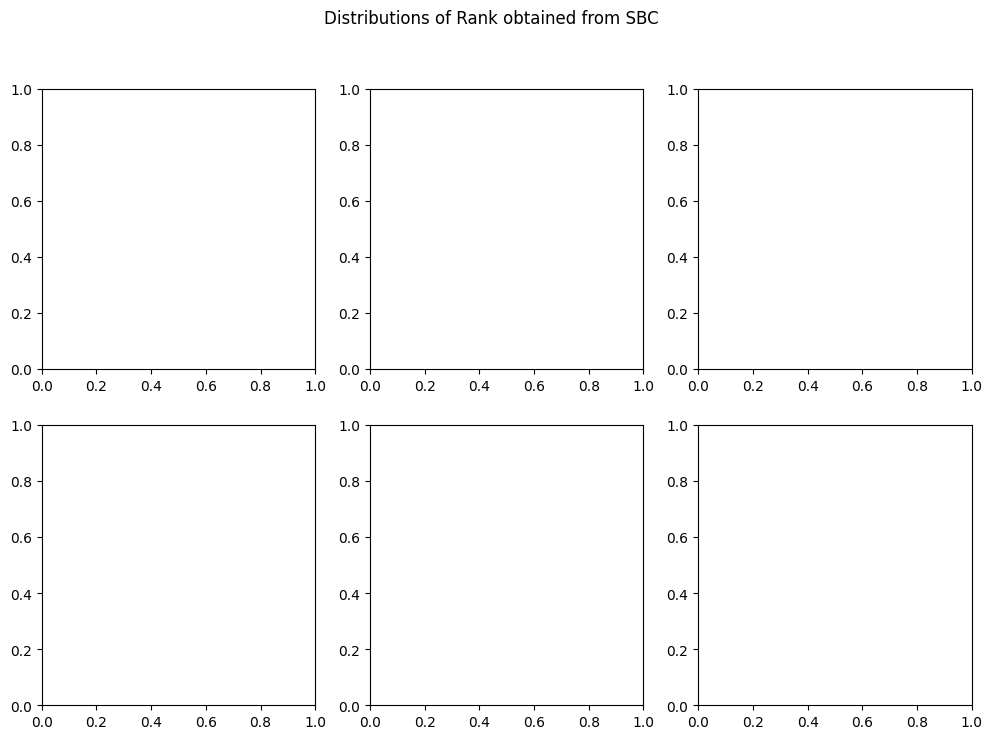

In [9]:
import matplotlib.pyplot as plt

plot_titles= ["log(p_0)", "log(r_s)", "gamma", "r_star/r_s", "r_a/r_star"]

fig,axs= plt.subplots(2, 3, figsize=(12,8))

fig.suptitle("Distributions of Rank obtained from SBC")

# rank = # of samples less than \ntrue theta in each posterior sample
for i in range(3):
    axs[0, i].hist(ranks[0][:,i], bins=30, edgecolor="black")
    axs[0, i].set_title(plot_titles[i])
    axs[0, i].set_xlabel("Rank")
    axs[0, i].set_ylabel("count")

for i in range(2):
    axs[1, i].hist(ranks[0][:,i + 3], bins=30, edgecolor="black")
    axs[1, i].set_title(plot_titles[i + 3])
    axs[1, i].set_xlabel("Rank")
    axs[1, i].set_ylabel("count")

plt.tight_layout()
plt.show()

### Hypothesis Testing

In [73]:
from sbi.diagnostics import calc_misspecification_logprob

test_theta = prior.sample((1,))
test_x = generate_galaxy_bunch(prior.sample((1,)))

In [75]:

sample_theta = prior.sample((1000,))
x_val = generate_galaxy_bunch(sample_theta)

In [ ]:
# Unconditional estimator for fixed theta
from sbi.neural_nets.estimators import UnconditionalDensityEstimator
class UnconditionalEstimator():
    def __init__(self, model, theta):
        # super().__init__()
        self.model = model
        self.theta = theta

    def log_prob(self, x):
        return self.model.log_prob(x, condition= self.theta.repeat(x.shape[0], 1))
    
    


In [63]:
a = UnconditionalEstimator(likelihood_estimator, test_theta)

In [72]:
# a.theta
test_x.shape

torch.Size([1, 5])

In [68]:
a.log_prob(generate_galaxy_bunch(test_theta))

tensor([[-10.0066,  -5.1364,  -9.9083, -13.4259,  -9.5116,  -9.7737, -13.5220,
         -12.8171,  -6.2870, -14.6676,  -7.2843,  -9.4507, -16.9688, -11.7110,
         -10.6786, -10.6550,  -4.6543, -10.3796,  -9.9561,  -9.5659, -10.7424,
          -7.9748,  -6.2329, -18.1140,  -6.1230,  -8.3160, -20.1569,  -4.7743,
          -6.9913,  -9.7815, -10.1666,  -9.5004, -11.9730, -16.1069, -12.7717,
         -11.1038,  -9.0079, -10.2789,  -9.3477,  -5.7846, -11.8339, -15.7596,
          -7.4043, -12.9925,  -9.3354,  -7.1244, -10.4841, -13.0167, -12.9277,
          -8.2852, -10.8306, -17.4314, -10.2228, -11.6953,  -8.9795,  -7.4786,
         -19.6991,  -8.2712,  -6.8810, -15.4612,  -8.0689, -20.2422, -11.7227,
          -5.3757, -19.7808,  -5.2223,  -8.3774, -11.0294, -13.6478, -14.2448,
         -14.7541, -13.7563,  -6.9172, -13.4820, -10.7549, -15.9738, -13.5461,
          -8.1773,  -7.9233, -10.6645, -10.4324,  -4.8757,  -7.9058,  -8.2591,
          -8.8009, -12.1545, -12.1386,  -5.2715,  -6

In [84]:
calc_misspecification_logprob(x_val, test_x, UnconditionalEstimator(likelihood_estimator, test_theta))


TypeError: Can't instantiate abstract class UnconditionalEstimator with abstract methods loss, sample

### MCMC

In [8]:
import emcee

In [9]:
class EmceePosteriorWrapper:
    def __init__(self, model, x_obs, prior):
        self.model = model
        # Ensure the observation is always (1, 6)
        self.x_obs = x_obs.view(1, -1) 
        self.prior = prior

    def __call__(self, theta_np):
        """
        emcee calls this function. 

        - theta_np: numpy array of shape (5,)
        """
        # 1. Convert to torch (1, 5)
        theta = torch.as_tensor(theta_np, dtype=torch.float32).view(1, -1)

        # 2. Log-Prior range check
        lp = self.prior.log_prob(theta).item()
        if lp == -float('inf'):
            return -np.inf # so always lower probability and MCMC will not go to this step

        # 3. Log-Likelihood from NLE
        # We use no_grad because emcee doesn't need derivatives
        with torch.no_grad():
            try:
                # log p(x_obs | theta)
                # First arg: Data (Size 6), Second arg: Condition (Size 5)
                ll = self.model.log_prob(self.x_obs, condition=theta).item()
            except Exception:
                # If the neural network hits a numerical error, reject the step
                return -np.inf

        # Posterior = Prior + Likelihood
        return lp + ll

# --- Execution ---

# 1. Prepare data
th_true = prior.sample((1,))
x_obs = generate_galaxy_bunch(th_true)

# 2. Initialize our callable wrapper
# We include the prior here so the MCMC knows the boundaries
post_func = EmceePosteriorWrapper(likelihood_estimator, x_obs, prior)

# 3. Setup emcee
ndim = 5
nwalkers = 32
sampler = emcee.EnsembleSampler(nwalkers, ndim, post_func)

# 4. Start walkers in a small cloud around a random spot in the prior
initial_pos = prior.sample((nwalkers,)).numpy()

# 5. Run MCMC
print("Starting MCMC...")
sampler.run_mcmc(initial_pos, 500, progress=True)

# 6. View results (ignoring the first 100 steps of burn-in)
samples = sampler.get_chain(discard=100, flat=True)
print(f"Sampled {samples.shape[0]} points from the posterior.")

Starting MCMC...


100%|██████████| 500/500 [00:19<00:00, 25.92it/s]

Sampled 12800 points from the posterior.


In [22]:
# marginal median vs truth
print(np.median(samples, axis=0))
print(th_true)

[5.6361165  0.11855464 0.29293194 0.68091685 1.34602749]
tensor([[ 5.9777,  0.0401, -0.7530,  0.9015,  1.1751]])


In [ ]:
def generate_theta_dist(x_obs: torch.Tensor, likelihood_estimator, prior) -> torch.Tensor:
    """
    Run MCMC to sample thetas, given a set of observations (of stars of a single galaxy)

    - theta: tensor of generated thetas (10000) to run mcmc
    """
    size = x_obs.size()[0], 5
    q_2_5 = np.zeros(size)
    q_16 = np.zeros(size)
    q_50 = np.zeros(size)
    q_84 = np.zeros(size)
    q_97_5 = np.zeros(size)

    for i, row in enumerate(x_obs):

        # 2. Initialize our callable wrapper
        # We include the prior here so the MCMC knows the boundaries
        post_func = EmceePosteriorWrapper(likelihood_estimator, row, prior)

        # 3. Setup emcee
        ndim = 5
        nwalkers = 32
        sampler = emcee.EnsembleSampler(nwalkers, ndim, post_func)

        samples = []
        num_samples = 2
        for i in range(num_samples):
            samples.append(generate_single_posterior(sampler, prior))

        samples = np.vstack(samples)

        q_2_5[i], q_16[i], q_50[i], q_84[i], q_97_5[i] = np.quantile(samples, [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    return q_2_5, q_16, q_50, q_84, q_97_5

def generate_single_posterior(sampler, prior):
    # 4. Start walkers in a small cloud around a random spot in the prior
    initial_pos = prior.sample((sampler.nwalkers,)).numpy()

    # 5. Run MCMC
    chain_length = 500
    sampler.run_mcmc(initial_pos, chain_length, progress=True)

    # 6. View results (ignoring the first 100 steps of burn-in)
    samples = sampler.get_chain(discard=100, flat=True)


    return np.median(samples, axis=0)


In [12]:
import numpy as np
a = np.array([[1,2,3],
              [4,5,6],
              [7,8,9],
              [10,11,12]])
k, l = np.quantile(a, [0.5, 0.8], axis=0)
print(k)
print(l)

[5.5 6.5 7.5]
[ 8.2  9.2 10.2]


In [41]:
a = prior.sample((3,))
d = generate_galaxy_bunch(a)


In [43]:
a.size()

torch.Size([3, 5])

In [45]:
q_2_5, q_16, q_50, q_84, q_97_5 = generate_theta_dist(d, likelihood_estimator, prior)


100%|██████████| 500/500 [00:25<00:00, 19.56it/s]


In [48]:
print(q_16)
a[2]

[[ 0.          0.          0.          0.          0.        ]
 [ 6.25644539 -0.20355021  0.54625873  0.588286    1.26814904]
 [ 0.          0.          0.          0.          0.        ]]


tensor([ 6.3415, -0.9512, -0.5606,  0.3581,  1.5458])

## Real MCMC

In [28]:
from sbi.inference import MCMCPosterior, likelihood_estimator_based_potential


# Returns potential log(p(x_o|theta)p(theta))
theta = prior.sample((2,))
x_o = generate_galaxy_bunch(theta)




In [7]:
potential_fn, parameter_transform = likelihood_estimator_based_potential(
    likelihood_estimator, prior, x_o
)


In [8]:
posterior = MCMCPosterior(
    potential_fn, proposal=prior, 
    theta_transform=parameter_transform, 
    warmup_steps=10,
    num_chains=20,
    num_workers= 1,
    method = "slice_np_vectorized"
    )

In [ ]:

posterior.sample((1000,))

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains: 100%|██████████| 2200/2200 [00:20<00:00, 109.93it/s]


tensor([[ 7.8345, -0.7389,  0.9105,  0.5179,  1.6212],
        [ 7.5771, -0.7136,  1.1566,  0.4669,  1.3871],
        [ 7.8856, -0.8177,  1.1821,  0.4894,  1.3178],
        ...,
        [ 6.5633, -0.6057,  1.7617,  0.3538,  0.5014],
        [ 6.7916, -0.4906,  1.0843,  0.3356,  0.5120],
        [ 6.7418, -0.2960,  1.4028,  0.2855,  1.9679]])

In [29]:

def generate_samples(x_o, likelihood_estimator, prior, n_samples):
    """
    generate sample for single observed x (perhaps with multiple stars, but generated from same theta)

    - x_o: can be galaxy with n stars. n is the number of rows in x_o
    - n_samples: number of samples to generate
    """
    potential_fn, parameter_transform = likelihood_estimator_based_potential(
    likelihood_estimator, prior, x_o
)
    posterior = MCMCPosterior(
    potential_fn, proposal=prior, 
    theta_transform=parameter_transform, 
    warmup_steps=10,
    num_chains=20,
    num_workers= 1,
    method = "slice_np_vectorized"
    )

    samples = posterior.sample((n_samples,))

    return samples, torch.median(samples, dim=0)



In [24]:
th = prior.sample((1,)) 

x_o = generate_galaxy_complex(th, 100)[0]

In [30]:

s, m = generate_samples(x_o, likelihood_estimator, prior, 1000)


Running vectorized MCMC with 20 chains: 100%|██████████| 2200/2200 [00:12<00:00, 177.88it/s]


In [31]:
s

tensor([[ 5.5679,  0.6311,  0.1137,  0.9213,  1.7678],
        [ 5.5411,  0.5568,  0.8940,  0.8510,  0.9430],
        [ 5.4806,  0.6990,  0.4399,  0.8281,  1.2498],
        ...,
        [ 5.0093,  0.6693,  1.7962,  0.8115,  0.7447],
        [ 5.4845,  0.6958,  0.8352,  0.8135,  1.2412],
        [ 5.1984,  0.6823, -0.0279,  0.8684,  0.9702]])

In [33]:
print(m)
print(th)

torch.return_types.median(
values=tensor([5.4965, 0.6429, 0.6470, 0.9011, 1.3139]),
indices=tensor([537, 837, 976, 858, 636]))
tensor([[ 6.4938, -0.2344, -0.9491,  0.5665,  1.9098]])


In [ ]:
d

tensor([ 7.4907, -0.6249,  1.1255,  0.4955,  1.0769])

In [44]:
theta = prior.sample((10,))

observations = generate_galaxy_complex(theta, 10)

In [45]:
generate_samples(observations[0], likelihood_estimator, prior, 100)

KeyboardInterrupt: 

In [48]:
medians = np.zeros((theta.size()[0], 5))
for i, x_obs in enumerate(observations):
    medians[i] = generate_samples(x_obs, likelihood_estimator, prior, 50)[1].values
































































Generating 20 MCMC inits via resample strategy: 100%|██████████| 20/20 [00:45<00:00,  2.25s/it]





















































































































































































































Running vectorized MCMC with 20 chains: 100%|██████████| 1260/1260 [00:26<00:00, 47.74it/s]































































Generating 20 MCMC inits via resample strategy: 100%|██████████| 20/20 [00:36<00:00,  1.82s/it]





















































































































































































































Running vectorized MCMC with 20 chains: 100%|██████████| 1260/1260 [00:30<00:00, 41.01it/s]































































Generatin

In [49]:
medians

array([[ 7.4668045 ,  0.68911541,  0.09693444,  0.9409095 ,  0.97098374],
       [ 5.51120377, -0.84086967, -0.07337475,  0.83395493,  1.76217794],
       [ 5.29047728,  0.06402421,  1.78912759,  0.45339245,  1.19971693],
       [ 5.12419081,  0.46645856, -0.49754947,  0.83268678,  1.36601496],
       [ 5.26510525, -0.87168837,  0.14943922,  0.53025347,  1.42156208],
       [ 6.28801537, -0.81592911, -0.1577605 ,  0.83311832,  1.55309057],
       [ 6.51506042,  0.30559409,  0.82470679,  0.90415168,  0.59723002],
       [ 5.70890951, -0.92045224, -0.04292345,  0.49512625,  0.80345201],
       [ 7.67410374,  0.36713457, -0.41977555,  0.89102471,  0.6719451 ],
       [ 6.40171099, -0.11161846, -0.2896319 ,  0.91531301,  0.59894478]])

### Evaluating mode performance after MCMC

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [9]:
theta = np.array([[ 7.1241302 ,  0.66374016,  0.39575458,  0.9095503 ,  1.5524396 ],
       [ 5.0120077 , -0.28242683, -0.64534795,  0.40998045,  0.79964083],
       [ 5.4366956 ,  0.14616907,  0.76994014,  0.37803382,  1.7080933 ],
       [ 5.152865  ,  0.19973612, -0.11629617,  0.83890903,  1.2824532 ],
       [ 5.427082  , -0.8767253 ,  0.21309412,  0.95337665,  0.8450142 ],
       [ 6.1541696 , -0.46240342, -0.68321735,  0.29397154,  1.3144537 ],
       [ 7.5961742 , -0.01333994, -0.07546133,  0.69747156,  1.0643023 ],
       [ 5.6533594 , -0.7394006 ,  1.3687379 ,  0.25903076,  0.92976195],
       [ 7.7967863 , -0.07062984,  0.834682  ,  0.5797917 ,  1.4774582 ],
       [ 6.8920145 , -0.7084626 ,  0.23117423,  0.7342016 ,  1.0910885 ]])

medians = np.array([[ 7.4668045 ,  0.68911541,  0.09693444,  0.9409095 ,  0.97098374],
       [ 5.51120377, -0.84086967, -0.07337475,  0.83395493,  1.76217794],
       [ 5.29047728,  0.06402421,  1.78912759,  0.45339245,  1.19971693],
       [ 5.12419081,  0.46645856, -0.49754947,  0.83268678,  1.36601496],
       [ 5.26510525, -0.87168837,  0.14943922,  0.53025347,  1.42156208],
       [ 6.28801537, -0.81592911, -0.1577605 ,  0.83311832,  1.55309057],
       [ 6.51506042,  0.30559409,  0.82470679,  0.90415168,  0.59723002],
       [ 5.70890951, -0.92045224, -0.04292345,  0.49512625,  0.80345201],
       [ 7.67410374,  0.36713457, -0.41977555,  0.89102471,  0.6719451 ],
       [ 6.40171099, -0.11161846, -0.2896319 ,  0.91531301,  0.59894478]])

for i in range(5):
    mse = mean_squared_error(theta[:,i], medians[:,i])
    r2 = r2_score(theta[:,i], medians[:,i])
    print(f"MSE for {i}th entry is {mse}")
    print(f"R^2 for {i}th entry is {r2}")
    print()


MSE for 0th entry is 0.18603169186205432
R^2 for 0th entry is 0.8104557259036113

MSE for 1th entry is 0.11977559489913206
R^2 for 1th entry is 0.4450403019041653

MSE for 2th entry is 0.6528693983237921
R^2 for 2th entry is -0.7203027764480008

MSE for 3th entry is 0.08842929562115333
R^2 for 3th entry is -0.4721337022271874

MSE for 4th entry is 0.3044520231314308
R^2 for 4th entry is -2.505728271283742

